In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import pickle

import numpy as np
import pandas as pd

import t2fpharm_study

pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', None)

In [2]:
filepath_lp_stats = Path("lp_stats.pkl")
filepath_lp_out = Path("lp_out.pkl")
filepath_cnn_stats = Path("cnn_stats2.pkl")
filepath_cnn_out = Path("cnn_out2.pkl")

In [3]:
manager = t2fpharm_study.manager()

In [4]:
def make_job_inputs_cnn(feature_max_radius: float, grid_spacing: float, match_max_distance: float | None):
    feature_max_volume = (4/3) * np.pi * feature_max_radius**3
    voxel_volume = grid_spacing**3
    feature_max_members = int(np.ceil(feature_max_volume / voxel_volume))
    min_neighbors = [6, 12, 18, 24, 50, 100, 500, 1000, 5000]
    max_distance = [feature_max_radius / i for i in range(1, len(min_neighbors) + 1)]
    max_vals_end = np.array([-0.7, -0.8, -1.2, -2.0, -2.0])
    jobs = []
    for min_members in [n for n in [5, 10, 15, 50, 100] if n < feature_max_members ]:
        for max_vals in [max_vals_end/i for i in np.arange(1, 3, 0.5)]:
            job_inputs = {
                "method": "cnn",
                "kwargs": {
                    "max_value": max_vals,
                    "max_distance": max_distance,
                    "min_neighbors": min_neighbors,
                    "min_members": min_members,
                    "max_members": feature_max_members
                },
                "match_max_dist": match_max_distance,
            }
            jobs.append(job_inputs)
    return jobs

In [5]:
cnn_inputs = make_job_inputs_cnn(
    feature_max_radius=2,
    grid_spacing=manager.pocket_params["grid_spacing"],
    match_max_distance=2,
)

if not filepath_cnn_stats.is_file():
    cnn_stats, cnn_out = manager.run(cnn_inputs)
    with open(filepath_cnn_stats, "wb") as f:
        pickle.dump(cnn_stats, f)
    with open(filepath_cnn_out, "wb") as f:
        pickle.dump(cnn_out, f)
else:
    with open(filepath_cnn_stats, "rb") as f:
        cnn_stats = pickle.load(f)
    with open(filepath_cnn_out, "rb") as f:
        cnn_out = pickle.load(f)

Creating jobs:   0%|          | 0/32 [00:00<?, ?job/s]

Running jobs:   0%|          | 0/640 [00:00<?, ?job/s]

In [22]:
cnn_out[list(cnn_out.keys())[0]]["pharm"].features

[autoreload of t2fpharm_study.manager failed: Traceback (most recent call last):
  File "/usr/local/Caskroom/miniforge/base/envs/opencadd/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 283, in check
    superreload(m, reload, self.old_objects)
  File "/usr/local/Caskroom/miniforge/base/envs/opencadd/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 483, in superreload
    module = reload(module)
             ^^^^^^^^^^^^^^
  File "/usr/local/Caskroom/miniforge/base/envs/opencadd/lib/python3.12/importlib/__init__.py", line 131, in reload
    _bootstrap._exec(spec, module)
  File "<frozen importlib._bootstrap>", line 866, in _exec
  File "<frozen importlib._bootstrap_external>", line 995, in exec_module
  File "<frozen importlib._bootstrap_external>", line 1133, in get_code
  File "<frozen importlib._bootstrap_external>", line 1063, in source_to_code
  File "<frozen importlib._bootstrap>", line 488, in _call_with_frames_removed
  File "/Volumes/T7

,instance,type,label,n_points,volume,radius,center,points
0,0,OA,1,49,1.323,0.681016,"[3.5600407133297045, 29.640960549335087, 6.232...","[[2.757999897003174, 29.84300136566162, 6.1649..."
1,0,OA,2,23,0.621,0.529258,"[-6.189826189953349, 25.538653539574664, 13.31...","[[-6.842000102996826, 25.64300136566162, 13.96..."
2,0,OA,3,21,0.567,0.513450,"[-3.542000102996826, 32.15728707994734, 11.907...","[[-4.4420001029968255, 32.84300136566162, 13.6..."


In [23]:
cnn_out[list(cnn_out.keys())[0]]["matches"]

[autoreload of t2fpharm_study.manager failed: Traceback (most recent call last):
  File "/usr/local/Caskroom/miniforge/base/envs/opencadd/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 283, in check
    superreload(m, reload, self.old_objects)
  File "/usr/local/Caskroom/miniforge/base/envs/opencadd/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 483, in superreload
    module = reload(module)
             ^^^^^^^^^^^^^^
  File "/usr/local/Caskroom/miniforge/base/envs/opencadd/lib/python3.12/importlib/__init__.py", line 131, in reload
    _bootstrap._exec(spec, module)
  File "<frozen importlib._bootstrap>", line 866, in _exec
  File "<frozen importlib._bootstrap_external>", line 995, in exec_module
  File "<frozen importlib._bootstrap_external>", line 1133, in get_code
  File "<frozen importlib._bootstrap_external>", line 1063, in source_to_code
  File "<frozen importlib._bootstrap>", line 488, in _call_with_frames_removed
  File "/Volumes/T7

,ligand_idx,instance,label,type,match,distance,max_distance
0,0,0,1.0,OA,True,1.834372,2.0
1,1,0,NaN,HD,False,NaN,NaN
2,2,0,NaN,HD,False,NaN,NaN
3,3,0,NaN,C,False,NaN,NaN
4,4,0,NaN,C,False,NaN,NaN
5,5,0,NaN,C,False,NaN,NaN
6,6,0,NaN,C,False,NaN,NaN
7,7,0,NaN,C,False,NaN,NaN
8,8,0,NaN,C,False,NaN,NaN
9,9,0,NaN,C,False,NaN,NaN


In [21]:
cnn_stats

,pdb_id,method,job_idx,feats_receptor,feats_ligand,matches,match_percent,min_members,max_value
0,1AQ1,cnn,0,3,10,1,10.0,5,"(-0.7, -0.8, -1.2, -2.0, -2.0)"
1,1AQ1,cnn,1,20,10,4,40.0,5,"(-0.4666666666666666, -0.5333333333333333, -0...."
2,1AQ1,cnn,2,30,10,3,30.0,5,"(-0.35, -0.4, -0.6, -1.0, -1.0)"
3,1AQ1,cnn,3,38,10,2,20.0,5,"(-0.27999999999999997, -0.32, -0.48, -0.8, -0.8)"
4,1AQ1,cnn,4,3,10,1,10.0,10,"(-0.7, -0.8, -1.2, -2.0, -2.0)"
...,...,...,...,...,...,...,...,...,...
635,3EML,cnn,15,12,7,1,14.285714,50,"(-0.27999999999999997, -0.32, -0.48, -0.8, -0.8)"
636,3EML,cnn,16,0,7,0,0.0,100,"(-0.7, -0.8, -1.2, -2.0, -2.0)"
637,3EML,cnn,17,12,7,2,28.571429,100,"(-0.4666666666666666, -0.5333333333333333, -0...."
638,3EML,cnn,18,11,7,1,14.285714,100,"(-0.35, -0.4, -0.6, -1.0, -1.0)"


In [6]:
cnn_stats["min_members"] = cnn_stats["job_idx"].apply(lambda idx: cnn_inputs[idx]["kwargs"]["min_members"])
cnn_stats["max_value"] = cnn_stats["job_idx"].apply(lambda idx: tuple(cnn_inputs[idx]["kwargs"]["max_value"].tolist()))
cnn_avg_match_percents = (
    cnn_stats
    .groupby(['min_members', 'max_value'])['match_percent']
    .mean()
    .reset_index(name='avg_match_percent')
    .pivot(
        index='min_members',
        columns='max_value',
        values='avg_match_percent'
    )
    .astype(float)
)

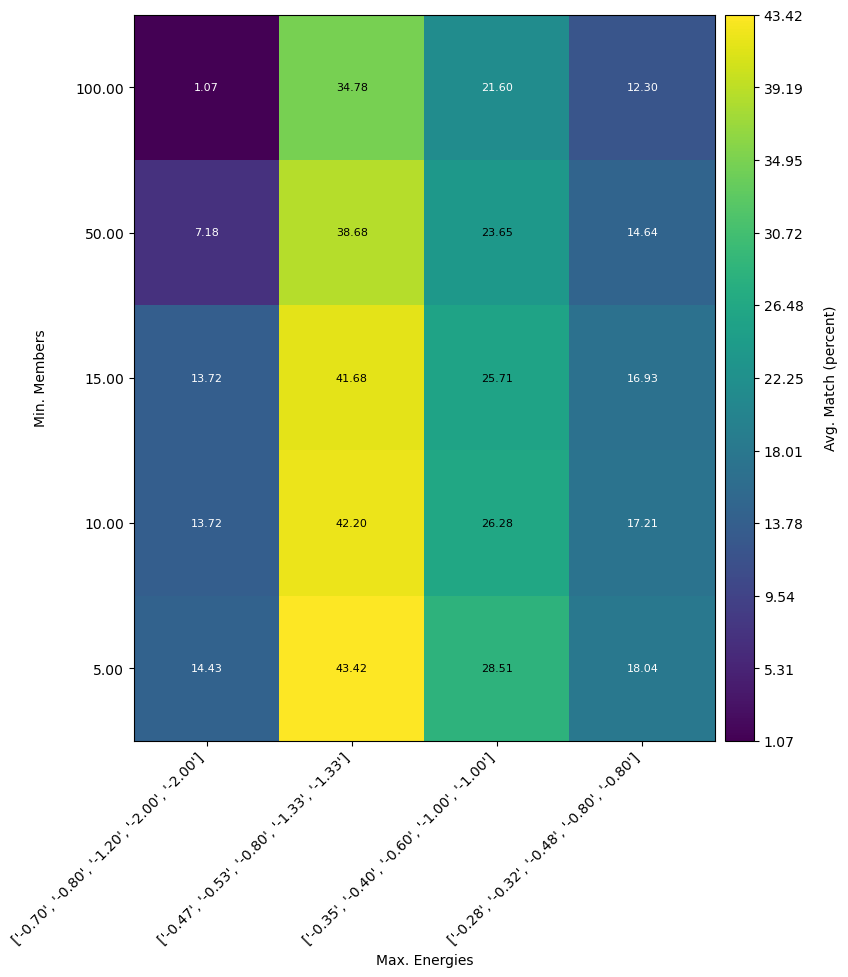

In [16]:
manager.plot_match_ratio_heatmap(
    cnn_avg_match_percents,
    row_label='Min. Members',
    col_label="Max. Energies",
    val_label="Avg. Match (percent)",
    fig_width=8,
)

In [8]:
cnn_num_features = (
    cnn_stats
    .groupby(['min_members', 'max_value'])['feats_receptor']
    .mean()
    .reset_index(name='avg_feat_count')
    .pivot(
        index='min_members',
        columns='max_value',
        values='avg_feat_count'
    )
    .astype(float)
)

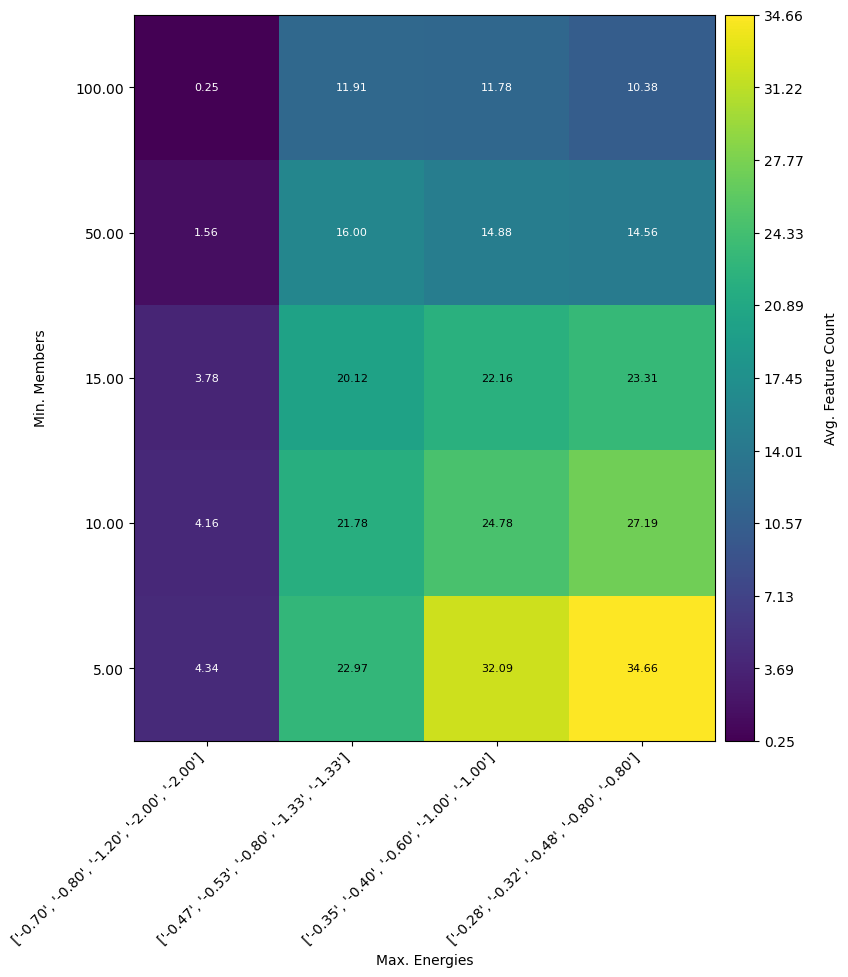

In [18]:
manager.plot_match_ratio_heatmap(
    cnn_num_features,
    row_label='Min. Members',
    col_label="Max. Energies",
    val_label="Avg. Feature Count",
    fig_width=8,
)

In [10]:
def make_job_inputs_lp(grid_spacing: float, match_max_distance: float | None):
    jobs = []
    for min_distance in np.arange(grid_spacing, 5, grid_spacing):
        for max_feature in [5, 10, 15, 20, 30, 40, 50, 60, 70, 80, 90, 100, 500, 1000]:
            job_inputs = {
                "method": "largest_peaks",
                "kwargs": {
                    "min_distance": min_distance,
                    "max_features": max_feature
                },
                "match_max_dist": match_max_distance,
            }
            jobs.append(job_inputs)
    return jobs

In [11]:
lp_inputs = make_job_inputs_lp(
    grid_spacing=manager.pocket_params["grid_spacing"],
    match_max_distance=2,
)

if not filepath_lp_stats.is_file():
    lp_stats, lp_out = manager.run(lp_inputs)
    with open(filepath_lp_stats, "wb") as f:
        pickle.dump(lp_stats, f)
    with open(filepath_lp_out, "wb") as f:
        pickle.dump(lp_out, f)
else:
    with open(filepath_lp_stats, "rb") as f:
        lp_stats = pickle.load(f)
    with open(filepath_lp_out, "rb") as f:
        lp_out = pickle.load(f)

In [12]:
lp_stats["max_features"] = lp_stats["job_idx"].apply(lambda idx: lp_inputs[idx]["kwargs"]["max_features"])
lp_stats["min_distance"] = lp_stats["job_idx"].apply(lambda idx: lp_inputs[idx]["kwargs"]["min_distance"])
avg_match_percents = (
    lp_stats
    .groupby(['max_features', 'min_distance'])['match_percent']
    .mean()
    .reset_index(name='avg_match_percent')
    .pivot(
        index='min_distance',
        columns='max_features',
        values='avg_match_percent'
    )
    .astype(float)
)

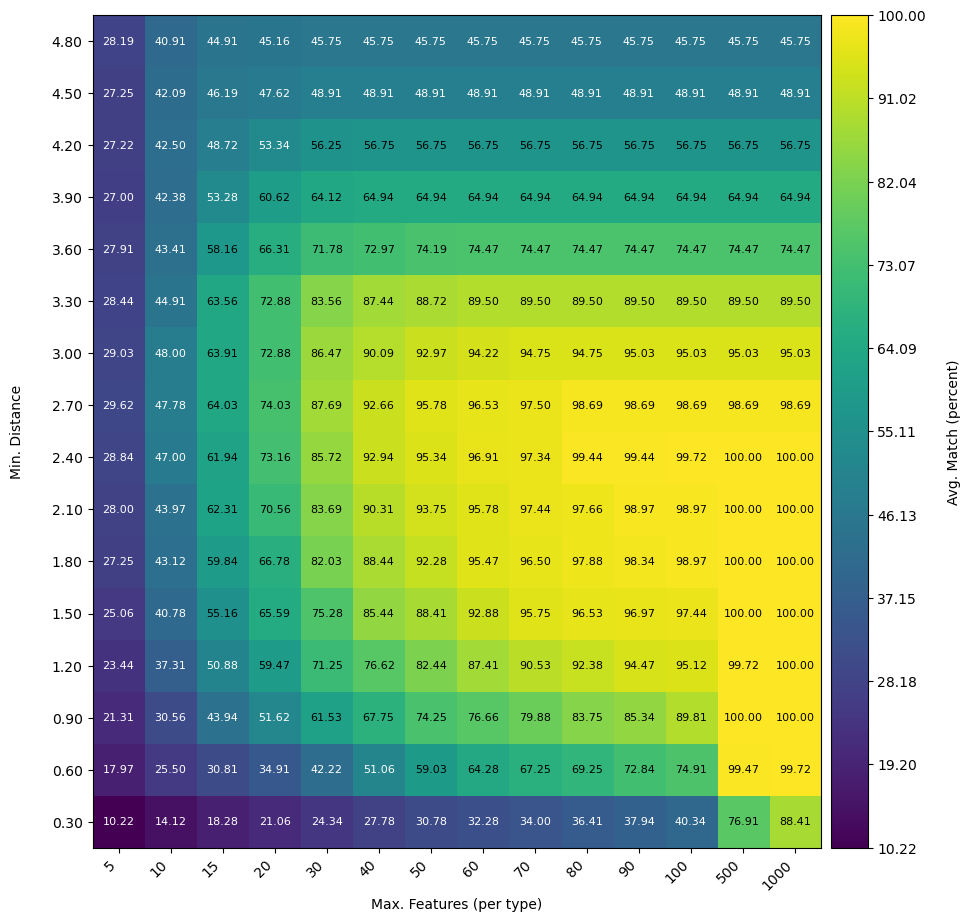

In [13]:
manager.plot_match_ratio_heatmap(
    avg_match_percents,
    row_label='Min. Distance',
    col_label="Max. Features (per type)",
    val_label="Avg. Match (percent)",
)